In [51]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'


matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [52]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [53]:
HP = uniprot.uniprot_fasta_to_proteome('/home/wenyuantong/Desktop/data/combined.fasta')
#27977

In [33]:
#si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/RIN4_domain_all_cut.tsv', skip_bad=True, safe=False)

In [54]:
si_domains.add_domains_from_file(HP, '/home/wenyuantong/Desktop/data/P-body_domain_all_cut.tsv', skip_bad=True, safe=False)

In [55]:
HP.domains[0]

|Domain: N-terminal_1 (1-80, len=80) in protein HopX1a

In [56]:
# build set of domains to work with - default in paper is IDRs between 100 and 150 inclusive
LOWER = 30
UPPER = 80
size_d = []
for d in HP.domains:
    #display(d)
    if len(d) >= LOWER and len(d) <= UPPER:
        size_d.append(d)

# construct name-to-sequence mapping
name2seq = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2seq[d1_name] = d1.sequence


# construct name-to-sequence mapping
name2domain = {}
for d1 in size_d:
    d1_name = d1.protein.unique_ID + "_" + d1.domain_name
    name2domain[d1_name] = d1

print(f"Found {len(size_d)} IDRs; this will be {len(size_d)**2} epsilon calculations")

Found 828 IDRs; this will be 685584 epsilon calculations


In [57]:
mode = 'mpipi'

In [58]:
# if set to True we recompute from scratch and save the newly computed values
# to the pickle files, if False, we read from recomputed pickle files
RECOMPUTE = True

if mode == 'mpipi':
    if RECOMPUTE:
        cross_interaction = {}
        
        for d1 in tqdm(size_d):
            
            d1_name = d1.protein.unique_ID + "_" + d1.domain_name
            #print(d1_name)
            cross_interaction[d1_name] = {}        
                
            for d2 in size_d:
                d2_name = d2.protein.unique_ID + "_" + d2.domain_name
                
                cross_interaction[d1_name][d2_name] = mf.epsilon(d1.sequence, d2.sequence)
                
            with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'wb') as file:
            # Use pickle to serialize the dictionary and write it to the file
                pickle.dump(cross_interaction, file)
    else:
        # load
    
        with open('/home/wenyuantong/Desktop/data/15005027/finches/figure_4/cross_interaction_mpipi.pkl', 'rb') as file:
            # Load the dictionary back from the pickle file
            cross_interaction = pickle.load(file)



  0%|          | 0/828 [00:00<?, ?it/s]

In [60]:
all_cross_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
        else:
            repulsive = repulsive + 1
    all_cross_interactions.append(tmp)
all_cross_interactions = np.array(all_cross_interactions)

In [61]:
print(f'Percentage of pairs that are attractive: {round(100*attractive/(repulsive+attractive),2)}%')
print(f'Percentage of pairs that are repulsive: {round(100*repulsive/(repulsive+attractive),2)}%')

Percentage of pairs that are attractive: 9.69%
Percentage of pairs that are repulsive: 90.31%


In [62]:
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

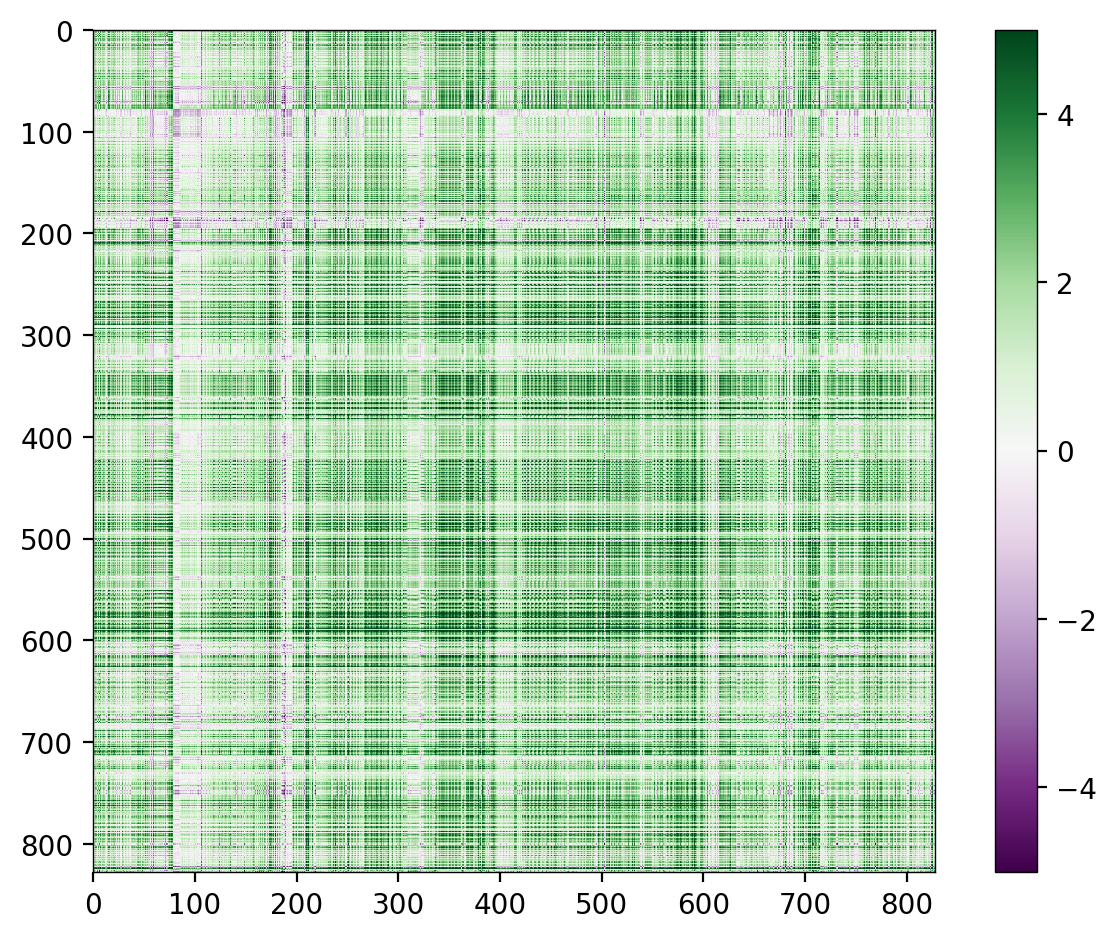

In [63]:
if mode == 'calvados':
    plt.imshow(all_cross_interactions, vmin=-15, vmax=15,cmap='PRGn',interpolation='None')
elif mode == 'mpipi':
    plt.imshow(all_cross_interactions, vmin=-5, vmax=5,cmap='PRGn',interpolation='None')

plt.colorbar()
plt.tight_layout()
plt.savefig(f'/home/wenyuantong/Desktop/figures/RIN4_all_effectors_matrix_{mode}.pdf')

In [64]:
import pandas as pd

In [65]:
#all_cross_interactions
all_atr_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_atr_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [66]:
#all_cross_interactions
all_interactions = []
attractive = 0
repulsive = 0
for k1 in cross_interaction:
    tmp = []
    for k2 in cross_interaction:
        tmp.append(cross_interaction[k1][k2])
        if cross_interaction[k1][k2] < 0:
            attractive = attractive+1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
            
        else:
            repulsive = repulsive + 1
            all_interactions.append([k1,k2,(cross_interaction[k1][k2])])
    #all_cross_interactions.append(tmp)
#all_cross_interactions = np.array(all_cross_interactions)

In [73]:
#all_atr_interactions
all_df = pd.DataFrame(all_interactions, columns=['IDR1', 'IDR2','E_value'])

# Display the DataFrame
display(all_df)

,IDR1,IDR2,E_value
0,HopX1a_N-terminal_1_1_80,HopX1a_N-terminal_1_1_80,3.790395
1,HopX1a_N-terminal_1_1_80,HopX1a_Middle_1_200_247,2.613458
2,HopX1a_N-terminal_1_1_80,HopX1a_C-terminal_1_298_377,3.844718
3,HopX1a_N-terminal_1_1_80,HopX1c_N-terminal_1_1_80,3.180637
4,HopX1a_N-terminal_1_1_80,HopX1c_Middle_1_212_267,1.629701
...,...,...,...
685579,Q9C658_IDP_8_561_611,Q9C658_IDP_4_241_320,-1.340929
685580,Q9C658_IDP_8_561_611,Q9C658_IDP_5_321_400,-0.382251
685581,Q9C658_IDP_8_561_611,Q9C658_IDP_6_401_480,-2.131918
685582,Q9C658_IDP_8_561_611,Q9C658_IDP_7_481_560,-3.426607


In [80]:
sorted_df_ascending = all_df.sort_values(by='E_value', ascending=True)

print("\nDataFrame sorted by 'price' (smallest to largest):")
display(sorted_df_ascending)


DataFrame sorted by 'price' (smallest to largest):


,IDR1,IDR2,E_value
156344,HopBL1b_Middle_1_412_491,HopAS1f_C-terminal_1_341_377,-10.033514
154688,HopBL1a_Middle_2_482_553,HopAS1f_C-terminal_1_341_377,-9.438213
156491,HopBL1b_Middle_1_412_491,Q9C658_IDP_8_561_611,-8.920029
156166,HopBL1b_Middle_1_412_491,HopM1s_C-terminal_1_801_836,-8.890329
154510,HopBL1a_Middle_2_482_553,HopM1s_C-terminal_1_801_836,-8.723607
...,...,...,...
483307,AvrE1q_IDP_1_1_80,AvrE1q_IDP_1_1_80,8.148415
483177,AvrE1q_IDP_1_1_80,AvrE1a_N-terminal_1_1_80,8.168007
375667,AvrE1a_N-terminal_1_1_80,AvrE1q_IDP_1_1_80,8.168007
375537,AvrE1a_N-terminal_1_1_80,AvrE1a_N-terminal_1_1_80,8.187587


In [59]:
# Define the word to search for
#search_word = 'Q8GYN5'

# Filter the DataFrame
#df1 = sorted_df_ascending[sorted_df_ascending['IDR1'].str.contains(search_word, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
#display(df1[0:30])

In [101]:
###P-BODY

# Define the word to search for
#search_word = ''
# Define the words to search for
search_words = ['Q9SJF3', 'Q9C658'] # Example with two words

# Create a regex pattern to search for either word
pattern = '|'.join(search_words)
# Filter the DataFrame

df1 = sorted_df_ascending[sorted_df_ascending['IDR1'].str.contains(pattern, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
684608,Q9C658_IDP_7_481_560,HopAS1f_C-terminal_1_341_377,-6.996367
681443,Q9C658_IDP_3_161_240,Q9C658_IDP_8_561_611,-6.121627
681296,Q9C658_IDP_3_161_240,HopAS1f_C-terminal_1_341_377,-5.859379
684944,Q9C658_IDP_8_561_611,HopBL1b_Middle_1_412_491,-5.686518
684430,Q9C658_IDP_7_481_560,HopM1s_C-terminal_1_801_836,-5.664558
684755,Q9C658_IDP_7_481_560,Q9C658_IDP_8_561_611,-5.375070
684942,Q9C658_IDP_8_561_611,HopBL1a_Middle_2_482_553,-5.279444
681384,Q9C658_IDP_3_161_240,HopM1l_C-terminal_1_264_294,-5.030562
684762,Q9C658_IDP_8_561_611,HopX1b_Middle_1_205_249,-5.007404
684974,Q9C658_IDP_8_561_611,AvrB2g_N-terminal_2_81_111,-4.972789


In [102]:
# Define the words to search for
search_words = ['Q9SJF3', 'Q9C658']  # Example with two words

# Create a regex pattern to search for either word
pattern = '|'.join(search_words)

# Filter the DataFrame to get rows WITHOUT the search words
df1 = df1[~df1['IDR2'].str.contains(pattern, case=False, na=False)]

display(df1[0:30])

,IDR1,IDR2,E_value
684608,Q9C658_IDP_7_481_560,HopAS1f_C-terminal_1_341_377,-6.996367
681296,Q9C658_IDP_3_161_240,HopAS1f_C-terminal_1_341_377,-5.859379
684944,Q9C658_IDP_8_561_611,HopBL1b_Middle_1_412_491,-5.686518
684430,Q9C658_IDP_7_481_560,HopM1s_C-terminal_1_801_836,-5.664558
684942,Q9C658_IDP_8_561_611,HopBL1a_Middle_2_482_553,-5.279444
681384,Q9C658_IDP_3_161_240,HopM1l_C-terminal_1_264_294,-5.030562
684762,Q9C658_IDP_8_561_611,HopX1b_Middle_1_205_249,-5.007404
684974,Q9C658_IDP_8_561_611,AvrB2g_N-terminal_2_81_111,-4.972789
677156,Q9SJF3_middle_1_141_220,HopAS1f_C-terminal_1_341_377,-4.714479
684696,Q9C658_IDP_7_481_560,HopM1l_C-terminal_1_264_294,-4.674856


In [48]:
# Define the word to search for
#search_word = ''

# Filter the DataFrame
#df1 = df1[~df1['IDR2'].str.contains(search_word, case=False, na=False)]

In [103]:
search_word = 'Q9SJF3'

# Filter the DataFrame
df1 = df1[df1['IDR1'].str.contains(search_word, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
677156,Q9SJF3_middle_1_141_220,HopAS1f_C-terminal_1_341_377,-4.714479
677984,Q9SJF3_middle_2_221_300,HopAS1f_C-terminal_1_341_377,-3.977981
676978,Q9SJF3_middle_1_141_220,HopM1s_C-terminal_1_801_836,-3.381442
677244,Q9SJF3_middle_1_141_220,HopM1l_C-terminal_1_264_294,-3.115616
677806,Q9SJF3_middle_2_221_300,HopM1s_C-terminal_1_801_836,-2.778573
678072,Q9SJF3_middle_2_221_300,HopM1l_C-terminal_1_264_294,-2.768711
677207,Q9SJF3_middle_1_141_220,HopD2h_C-terminal_1_157_187,-1.784703
678035,Q9SJF3_middle_2_221_300,HopD2h_C-terminal_1_157_187,-1.667171
678320,Q9SJF3_middle_3_301_334,HopBL1b_Middle_1_412_491,-1.561129
678350,Q9SJF3_middle_3_301_334,AvrB2g_N-terminal_2_81_111,-1.511228


In [104]:
search_word = 'HopM'

# Filter the DataFrame
df1 = df1[df1['IDR2'].str.contains(search_word, case=False, na=False)]

#print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:30])

,IDR1,IDR2,E_value
676978,Q9SJF3_middle_1_141_220,HopM1s_C-terminal_1_801_836,-3.381442
677244,Q9SJF3_middle_1_141_220,HopM1l_C-terminal_1_264_294,-3.115616
677806,Q9SJF3_middle_2_221_300,HopM1s_C-terminal_1_801_836,-2.778573
678072,Q9SJF3_middle_2_221_300,HopM1l_C-terminal_1_264_294,-2.768711
677013,Q9SJF3_middle_1_141_220,HopM1n_Middle_1_504_544,-1.398173
678900,Q9SJF3_middle_3_301_334,HopM1l_C-terminal_1_264_294,-1.139067
677841,Q9SJF3_middle_2_221_300,HopM1n_Middle_1_504_544,-1.132171
677016,Q9SJF3_middle_1_141_220,HopM1j_C-terminal_1_599_678,-0.715548
678634,Q9SJF3_middle_3_301_334,HopM1s_C-terminal_1_801_836,-0.705588
678672,Q9SJF3_middle_3_301_334,HopM1j_C-terminal_1_599_678,-0.525975


In [105]:

print(f"\nDataFrame filtered for rows containing '{search_word}':")
display(df1[0:10])


DataFrame filtered for rows containing 'HopM':


,IDR1,IDR2,E_value
676978,Q9SJF3_middle_1_141_220,HopM1s_C-terminal_1_801_836,-3.381442
677244,Q9SJF3_middle_1_141_220,HopM1l_C-terminal_1_264_294,-3.115616
677806,Q9SJF3_middle_2_221_300,HopM1s_C-terminal_1_801_836,-2.778573
678072,Q9SJF3_middle_2_221_300,HopM1l_C-terminal_1_264_294,-2.768711
677013,Q9SJF3_middle_1_141_220,HopM1n_Middle_1_504_544,-1.398173
678900,Q9SJF3_middle_3_301_334,HopM1l_C-terminal_1_264_294,-1.139067
677841,Q9SJF3_middle_2_221_300,HopM1n_Middle_1_504_544,-1.132171
677016,Q9SJF3_middle_1_141_220,HopM1j_C-terminal_1_599_678,-0.715548
678634,Q9SJF3_middle_3_301_334,HopM1s_C-terminal_1_801_836,-0.705588
678672,Q9SJF3_middle_3_301_334,HopM1j_C-terminal_1_599_678,-0.525975


In [50]:
#df1[0:10].to_csv("/home/wenyuantong/Desktop/data/RIN4_effector_top_10.csv", index=True)

In [106]:
df1[0:10].to_csv("/home/wenyuantong/Desktop/data/DCP1_HopM_effector_top_10.csv", index=True)